In [1]:
# Loading the dataset using pandas

import pandas as pd

df = pd.read_csv('../data/customer_shopping_behavior.csv')

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [10]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [11]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [12]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [13]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [14]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [15]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

## Exploratory Data Analysis (EDA)

Before moving to SQL, we visualize the cleaned dataset to understand distributions, spending patterns, and relationships between key variables. These plots inform which business questions are worth answering in SQL and later on the Power BI dashboard.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### 1. Distribution of Purchase Amount

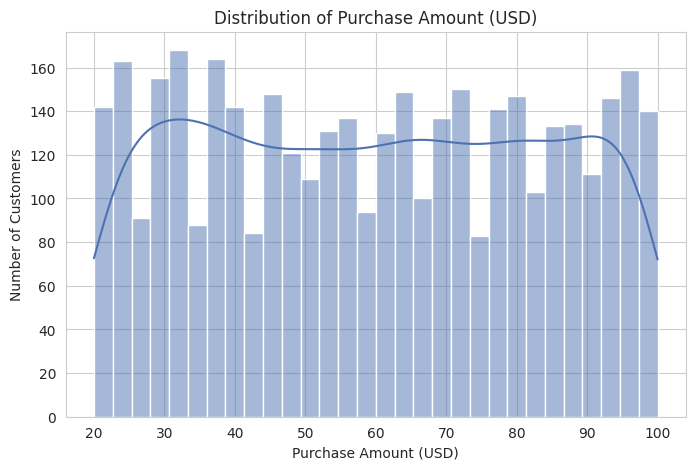

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['purchase_amount'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Purchase Amount (USD)')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Customers')
plt.show()

### 2. Revenue by Gender

/tmp/ipykernel_540/3094612892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_gender.index, y=revenue_by_gender.values, palette='Set2')


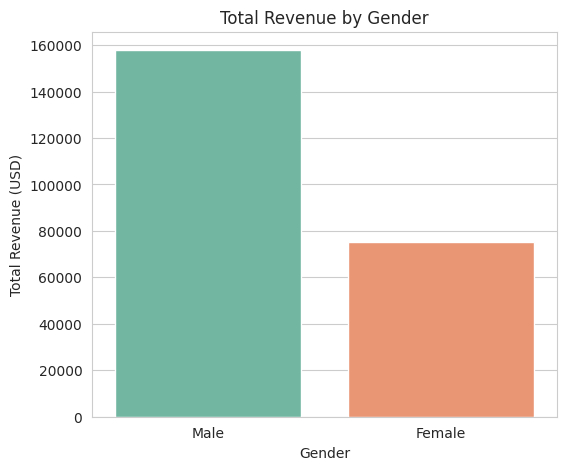

In [20]:
revenue_by_gender = df.groupby('gender')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,5))
sns.barplot(x=revenue_by_gender.index, y=revenue_by_gender.values, palette='Set2')
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue (USD)')
plt.show()

### 3. Top 10 Most Purchased Product Categories

/tmp/ipykernel_540/1073896654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')


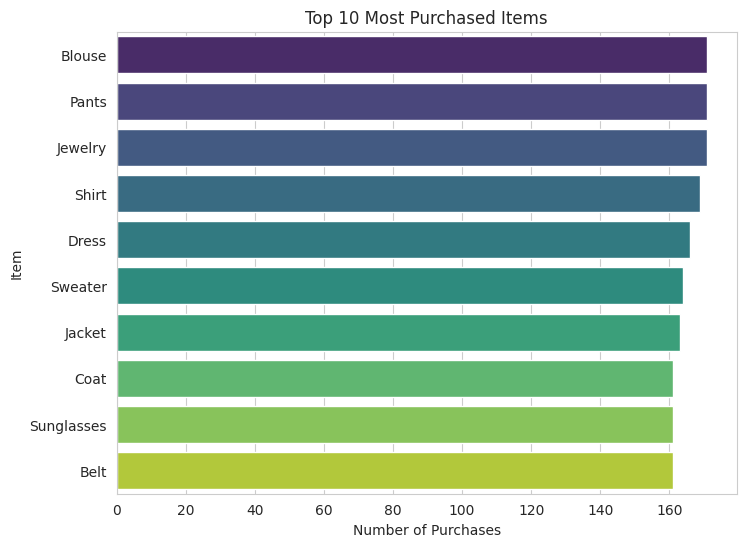

In [21]:
top_items = df['item_purchased'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Number of Purchases')
plt.ylabel('Item')
plt.show()

### 4. Average Purchase Amount by Age Group

/tmp/ipykernel_540/2214871234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_age.index, y=avg_by_age.values, palette='mako')


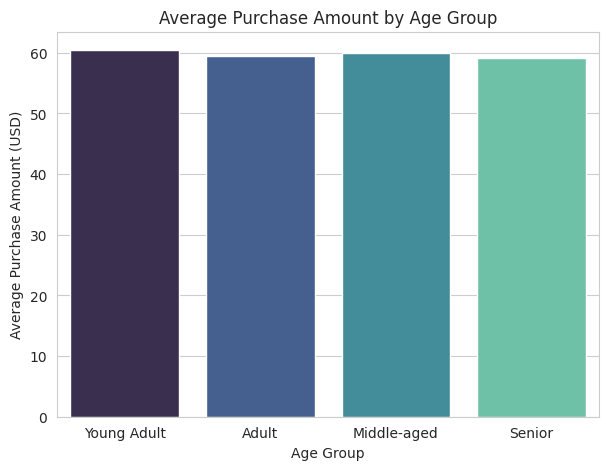

In [22]:
avg_by_age = df.groupby('age_group', observed=True)['purchase_amount'].mean().reindex(
    ['Young Adult','Adult','Middle-aged','Senior'])

plt.figure(figsize=(7,5))
sns.barplot(x=avg_by_age.index, y=avg_by_age.values, palette='mako')
plt.title('Average Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

### 5. Subscription Status vs. Average Spend

/tmp/ipykernel_540/2853138888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_spend.index, y=sub_spend.values, palette='crest')


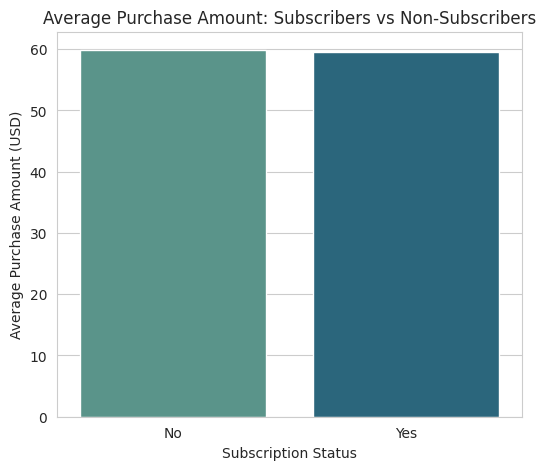

In [23]:
sub_spend = df.groupby('subscription_status')['purchase_amount'].mean()

plt.figure(figsize=(6,5))
sns.barplot(x=sub_spend.index, y=sub_spend.values, palette='crest')
plt.title('Average Purchase Amount: Subscribers vs Non-Subscribers')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

### 6. Review Rating Distribution

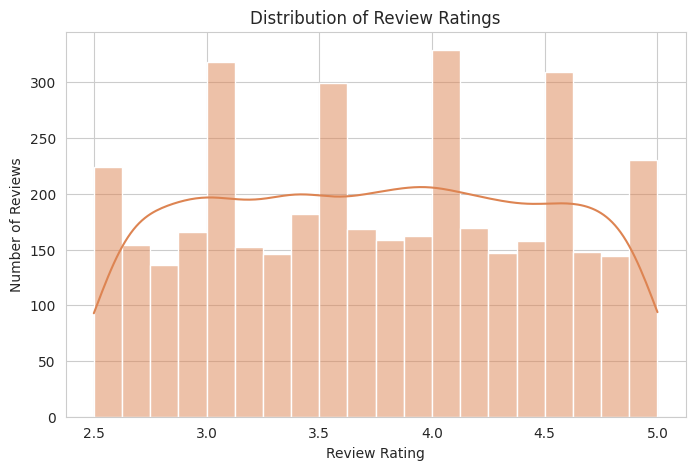

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['review_rating'], bins=20, kde=True, color='#DD8452')
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Number of Reviews')
plt.show()

### 7. Correlation Between Numeric Variables

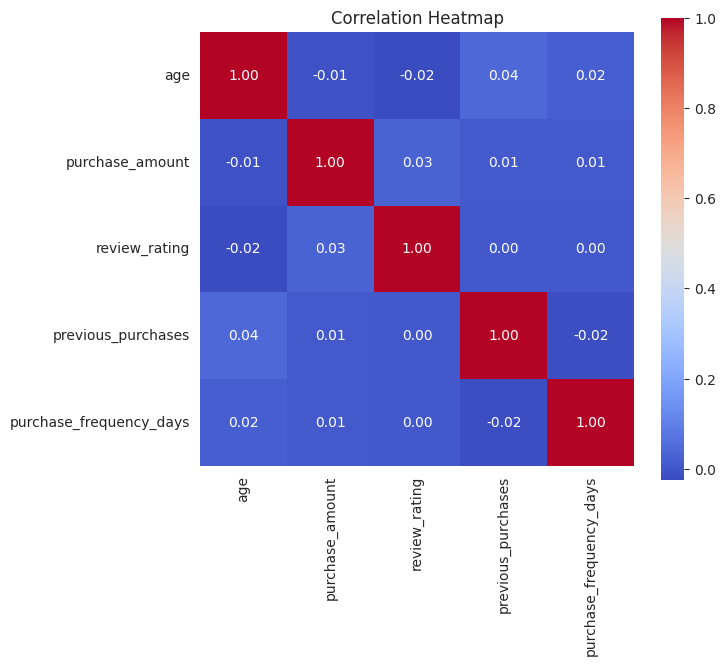

In [25]:
numeric_cols = ['age','purchase_amount','review_rating','previous_purchases','purchase_frequency_days']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

**EDA takeaways:**
- Purchase amounts are fairly evenly spread across the $20–$100 range, with no extreme outliers distorting the average.
- Gender-level revenue is close between Male and Female customers, so downstream segmentation should look at category and age group rather than gender alone.
- Clothing and accessories dominate purchase volume, which is useful for prioritizing inventory and discount strategy questions in SQL.
- Review ratings cluster in the 3.0–4.0 range with low variance, and numeric variables show weak linear correlation with each other — spend is driven more by categorical factors (category, subscription, shipping type) than by other numeric fields, which the SQL business questions explore directly.

## Connecting Python script to PostgreSQL

In [26]:
!pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [28]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
# NOTE: Never hardcode real credentials in a notebook you plan to commit to GitHub.
# Use environment variables (e.g. via python-dotenv) instead:
#   from dotenv import load_dotenv; import os
#   load_dotenv()
#   password = os.getenv('DB_PASSWORD')
password = "your_password"  # set during your local PostgreSQL install
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "customer_behavior"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.


## Code for MySQL

In [ ]:
!pip install pymysql sqlalchemy

In [ ]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "your_password"
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

## Code for MS SQL Server

In [3]:
!pip install pyodbc sqlalchemy 

In [ ]:
# Install required libraries

from sqlalchemy import create_engine
from urllib.parse import quote_plus

# SQL Server connection
username = "sa"
password = "your_password"
host = "localhost"
port = "1433"
database = "customer_behavior"

# Note: requires Microsoft ODBC Driver installed separately on your machine
driver = quote_plus("ODBC Driver 17 for SQL Server")
engine = create_engine(f"mssql+pyodbc://{username}:{password}@{host},{port}/{database}?driver={driver}")

# Write DataFrame to SQL Server
df.to_sql("customer", engine, if_exists="replace", index=False)

# Read back sample (SQL Server uses TOP instead of LIMIT)
pd.read_sql("SELECT TOP 5 * FROM customer;", engine)